In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow
from tensorflow.keras.models import load_model

In [2]:
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile

In [3]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [4]:
!pip install tf-keras -q

In [5]:
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array


In [6]:
from google.colab import drive

drive.mount("/content/gdrive")# monta uma pasta com o drive inteiro do content

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [7]:
path = "/content/gdrive/MyDrive/LAMIA - Bootcamp/card23/data/data"

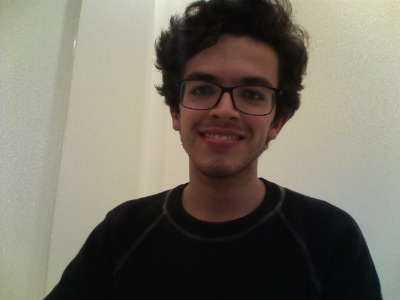

In [ ]:
imagem = cv2.imread('/content/gdrive/MyDrive/LAMIA - Bootcamp/card23/data/data/Material/Material/testes/teste_gabriel.png')# le a imagem ddo drive
cv2_imshow(imagem)

In [ ]:
cascade_faces = '/content/gdrive/MyDrive/LAMIA - Bootcamp/card23/data/data/Material/Material/haarcascade_frontalface_default.xml'
caminho_modelo= '/content/gdrive/MyDrive/LAMIA - Bootcamp/card23/data/data/Material/Material/modelo_01_expressoes.h5'
face_detetection = cv2.CascadeClassifier(cascade_faces)#carrega o detector com o xml
classificador_emocoes = load_model(caminho_modelo, compile = False)#carrega o moddelo pronto
expressoes = ["Raiva",'Nojo', "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]#list e labels validos(classes de emoções)

In [ ]:
original= imagem.copy()# faz uma copia para nao alterar a original
faces = face_detetection.detectMultiScale(original,scaleFactor=1.1,minNeighbors=3, minSize=(20,20)) # define o tamanho da face, nesse caso 20x20 pixels


In [11]:
faces

array([[162,  40, 128, 128]], dtype=int32)

In [ ]:
cinza = cv2.cvtColor(original,cv2.COLOR_BGR2GRAY)# converte a imagem para cinza

In [13]:
cinza.shape

(300, 400)

In [ ]:
roi = cinza[40:40 + 128,162:162 + 128]# roi é a regiao de interesse, entao somente a face sera plotada e seguida
# ele recorta exatamente a cabeça da pessoa

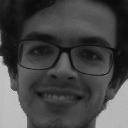

In [15]:
cv2_imshow(roi)

In [ ]:
roi.shape
# tamanho da area dde interesse

(128, 128)

array([[ 39,  37,  28, ...,  25,  29,  34],
       [ 34,  32,  25, ...,  24,  24,  29],
       [ 31,  33,  30, ...,  23,  22,  26],
       ...,
       [184, 185, 186, ..., 180, 181, 181],
       [184, 185, 186, ..., 179, 181, 180],
       [184, 185, 187, ..., 180, 181, 180]], dtype=uint8)
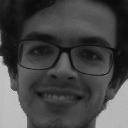

In [17]:
roi

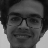

In [ ]:
roi =cv2.resize(roi,(48,48))
# remolda o tamanho da imagem para 48x48 para evitar que a rede fique muito pesada
cv2_imshow(roi)

In [20]:
roi.dtype

dtype('uint8')

In [ ]:
roi = roi.astype('float')
# converte para float, para realizar a normalização 0-1
roi.dtype

dtype('float64')

In [22]:
roi

array([[ 33.,  29.,  38., ...,  16.,  22.,  25.],
       [ 32.,  37.,  37., ...,  16.,  20.,  25.],
       [ 32.,  36.,  31., ...,  17.,  21.,  25.],
       ...,
       [186., 189., 189., ..., 181., 181., 180.],
       [185., 188., 189., ..., 180., 181., 180.],
       [185., 188., 188., ..., 179., 180., 181.]])

In [ ]:
roi = roi /255

array([[ 32.87058824,  28.88627451,  37.85098039, ...,  15.9372549 ,
         21.91372549,  24.90196078],
       [ 31.8745098 ,  36.85490196,  36.85490196, ...,  15.9372549 ,
         19.92156863,  24.90196078],
       [ 31.8745098 ,  35.85882353,  30.87843137, ...,  16.93333333,
         20.91764706,  24.90196078],
       ...,
       [185.27058824, 188.25882353, 188.25882353, ..., 180.29019608,
        180.29019608, 179.29411765],
       [184.2745098 , 187.2627451 , 188.25882353, ..., 179.29411765,
        180.29019608, 179.29411765],
       [184.2745098 , 187.2627451 , 187.2627451 , ..., 178.29803922,
        179.29411765, 180.29019608]])

In [24]:
roi

array([[ 33.,  29.,  38., ...,  16.,  22.,  25.],
       [ 32.,  37.,  37., ...,  16.,  20.,  25.],
       [ 32.,  36.,  31., ...,  17.,  21.,  25.],
       ...,
       [186., 189., 189., ..., 181., 181., 180.],
       [185., 188., 189., ..., 180., 181., 180.],
       [185., 188., 188., ..., 179., 180., 181.]])

In [ ]:
roi = img_to_array(roi)
# transforma o roi em shape aceitavel pelo tensorflow

In [26]:
roi.shape

(48, 48, 1)

In [ ]:
roi = np.expand_dims(roi,axis=0)
# adiciona mais uma dimensao

In [28]:
roi.shape

(1, 48, 48, 1)

In [ ]:
preds = classificador_emocoes.predict(roi)[0]
# faz a predição como o modelo somente da area de interesse, o [0] significa pegar a unica imagem, pois o tensor preve como se fosse varias imagens

1/1 [==============================] - 0s 467ms/step


In [ ]:
preds
# probabilidades da previsão

array([0.21418473, 0.02276106, 0.2919299 , 0.06915747, 0.13808861,
       0.1467035 , 0.11717469], dtype=float32)

In [ ]:
emotion_probabillity = np.max(preds)
# maior probabilidade
emotion_probabillity

np.float32(0.2919299)

In [32]:
preds.argmax()

np.int64(2)

In [ ]:
label = expressoes[preds.argmax()]
# adiciona o labela referente ao indice da probabilidade
label

'Medo'

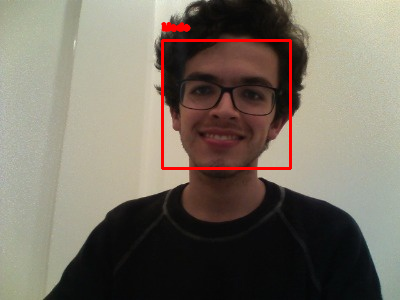

In [ ]:
cv2.putText(original, label,(162,40 - 10),cv2.FONT_HERSHEY_PLAIN,0.65,(0,0,255),2, cv2.LINE_AA)
# inputa o texto da label na imagem original
cv2.rectangle(original,(162,40), (162+128,40+128), (0,0,255),2)
# molda o retangulo na area dde interresse(face)
cv2_imshow(original)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
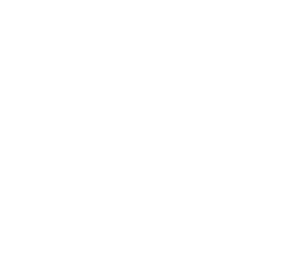

In [ ]:
probabilidades = np.ones((255,300,3),dtype = 'uint8')*255
# faz uma imagem branca para as barras serem alocadas
probabilidades

In [37]:
probabilidades.shape

(255, 300, 3)

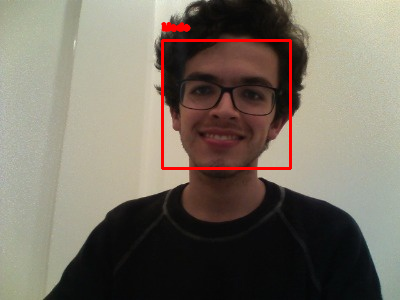

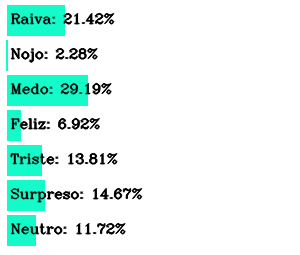

In [ ]:
cv2_imshow(original)
# printa a imagem original com o reconhecimento da face
if len(faces) ==1:
  for (i,(emotion,prob)) in enumerate(zip(expressoes, preds)):
    #print(i,emotion,prob)
    text = "{}: {:.2f}%".format(emotion,prob * 100)
    w = int(prob *300)
    cv2.rectangle(probabilidades,(7,(i*35)+5), (w,(i*35)+35),(200,250,20),-1)
    cv2.putText(probabilidades,text,(10,(i*35)+23),cv2.FONT_HERSHEY_COMPLEX, 0.45,(0,0,0),1,cv2.LINE_AA)
cv2_imshow(probabilidades)
# e em baixo esta a barrra de probabilidades que contem todas as probs do modelo